# Week 1 Seminar

A/B experiment analysis

### Перед анализом провели эксперимент (Random vs StickyArtist)
##### cd botify
##### docker-compose up -d --build --force-recreate --scale recommender=2

#### в отдельном терминале:
##### cd sim
##### source venv-sim/bin/activate #активируем предварительно созданное виртуальное окружение
##### python -m sim.run --episodes 1000 --config config/env.yml single --recommender remote --seed 31337

### Cкопируем логи из контейнеров к себе локально
#### из терминала:
##### cd botify
##### docker cp botify-recommender-1:/app/log/ /tmp/runAB/botify-log-1 
##### docker cp botify-recommender-2:/app/log/ /tmp/runAB/botify-log-2

In [1]:
import glob
from collections import namedtuple

import pandas as pd
import numpy as np
import scipy.stats as ss

import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

%matplotlib inline

In [4]:
!pip install scipy matplotlib

Looking in indexes: https://nexus.odkl.ru/repository/pypi-dev/simple, https://nexus.odkl.ru/repository/pypi-dev/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.9 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
experiment = "STICKY_ARTIST"

In [3]:
data = pd.concat([
    pd.read_json(data_path, lines=True)
    for data_path
    in ["/tmp/runAB/botify-log-1/log/data.json", "/tmp/runAB/botify-log-2/log/data.json"]
])

data["treatment"] = data["experiments"].map(lambda experiments: experiments[experiment])

In [4]:
data

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2026-03-13 07:48:15.796,3255,5091,1.00,1.955e-03,810.0,{'STICKY_ARTIST': 'C'},C
1,next,2026-03-13 07:48:15.808,3255,13662,0.16,2.439e-04,13410.0,{'STICKY_ARTIST': 'C'},C
2,next,2026-03-13 07:48:15.813,3255,12197,0.17,2.093e-04,9284.0,{'STICKY_ARTIST': 'C'},C
3,next,2026-03-13 07:48:15.821,7229,15,1.00,1.238e-03,16.0,{'STICKY_ARTIST': 'T1'},T1
4,next,2026-03-13 07:48:15.825,7229,17,0.61,3.505e-04,14.0,{'STICKY_ARTIST': 'T1'},T1
...,...,...,...,...,...,...,...,...,...
4179,next,2026-03-13 07:48:30.285,5020,8401,0.00,2.053e-04,8405.0,{'STICKY_ARTIST': 'T1'},T1
4180,next,2026-03-13 07:48:30.287,5020,3984,0.24,1.972e-04,8404.0,{'STICKY_ARTIST': 'T1'},T1
4181,next,2026-03-13 07:48:30.293,6128,81,1.00,2.077e-04,6811.0,{'STICKY_ARTIST': 'C'},C
4182,next,2026-03-13 07:48:30.295,6128,11751,0.02,1.175e-04,15719.0,{'STICKY_ARTIST': 'C'},C


In [5]:
!pwd

/Users/margarita.markova/recsys-course-spring-2026/jupyter


In [6]:
data

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2026-03-13 07:48:15.796,3255,5091,1.00,1.955e-03,810.0,{'STICKY_ARTIST': 'C'},C
1,next,2026-03-13 07:48:15.808,3255,13662,0.16,2.439e-04,13410.0,{'STICKY_ARTIST': 'C'},C
2,next,2026-03-13 07:48:15.813,3255,12197,0.17,2.093e-04,9284.0,{'STICKY_ARTIST': 'C'},C
3,next,2026-03-13 07:48:15.821,7229,15,1.00,1.238e-03,16.0,{'STICKY_ARTIST': 'T1'},T1
4,next,2026-03-13 07:48:15.825,7229,17,0.61,3.505e-04,14.0,{'STICKY_ARTIST': 'T1'},T1
...,...,...,...,...,...,...,...,...,...
4179,next,2026-03-13 07:48:30.285,5020,8401,0.00,2.053e-04,8405.0,{'STICKY_ARTIST': 'T1'},T1
4180,next,2026-03-13 07:48:30.287,5020,3984,0.24,1.972e-04,8404.0,{'STICKY_ARTIST': 'T1'},T1
4181,next,2026-03-13 07:48:30.293,6128,81,1.00,2.077e-04,6811.0,{'STICKY_ARTIST': 'C'},C
4182,next,2026-03-13 07:48:30.295,6128,11751,0.02,1.175e-04,15719.0,{'STICKY_ARTIST': 'C'},C


In [7]:
data[
    (data["treatment"] == "T1") & 
    (data["user"]== 5020)
].sort_values("timestamp")

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
4177,next,2026-03-13 07:48:30.281,5020,1786,1.00,2.899e-04,3987.0,{'STICKY_ARTIST': 'T1'},T1
4178,next,2026-03-13 07:48:30.282,5020,3987,0.17,2.863e-04,8401.0,{'STICKY_ARTIST': 'T1'},T1
4178,next,2026-03-13 07:48:30.283,5020,8401,0.39,2.148e-04,8402.0,{'STICKY_ARTIST': 'T1'},T1
4179,next,2026-03-13 07:48:30.284,5020,8402,0.49,1.976e-04,8401.0,{'STICKY_ARTIST': 'T1'},T1
4179,next,2026-03-13 07:48:30.285,5020,8401,0.00,2.053e-04,8405.0,{'STICKY_ARTIST': 'T1'},T1
4180,next,2026-03-13 07:48:30.286,5020,8405,0.30,2.170e-04,3984.0,{'STICKY_ARTIST': 'T1'},T1
4181,last,2026-03-13 07:48:30.287,5020,8404,0.11,4.196e-05,NaN,{'STICKY_ARTIST': 'T1'},T1
4180,next,2026-03-13 07:48:30.287,5020,3984,0.24,1.972e-04,8404.0,{'STICKY_ARTIST': 'T1'},T1


In [8]:
data.groupby("treatment").count()

,message,timestamp,user,track,time,latency,recommendation,experiments
treatment,,,,,,,,
C,4285,4285,4285,4285,4285,4285,3805,4285
T1,4084,4084,4084,4084,4084,4084,3564,4084


## Visualize sessions

In [9]:
Session = namedtuple("Session", ["timestamp", "tracks", "time", "latency"])

def sessionize(user_data):
    sessions = []
    session = None
    for _, row in user_data.sort_values("timestamp").iterrows():
        if session is None:
            session = Session(row["timestamp"], 0, 0, 0)
        
        session = session._replace(
            tracks = session.tracks + 1, 
            time = session.time + row["time"],
            latency = session.latency + row["latency"] * 1000,
        )
        
        if row["message"] == "last":
            sessions.append(session._asdict())
            session = None
    return sessions

In [10]:
sessions = (
    data
    .groupby(["user", "treatment"])
    .apply(sessionize)
    .explode()
    .apply(pd.Series)
)

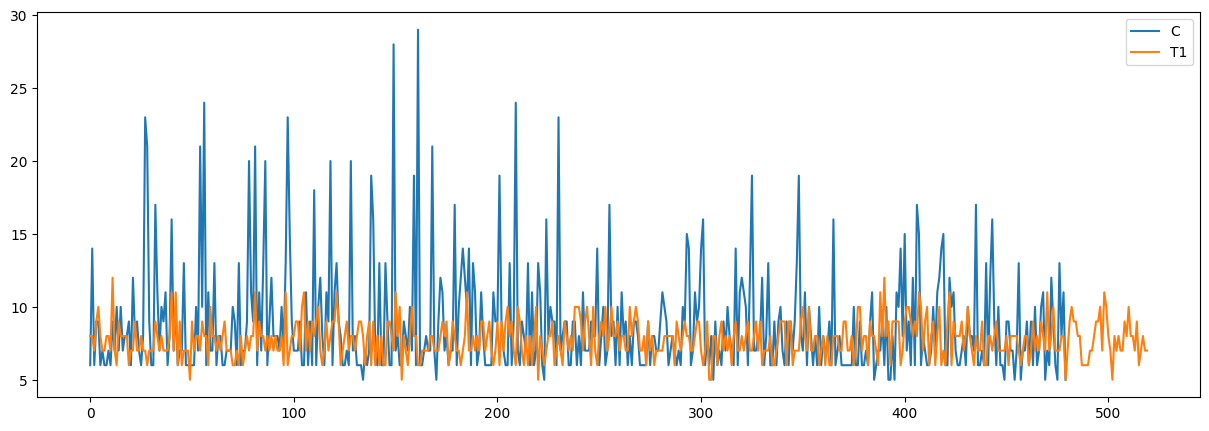

In [11]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["tracks"], label=treatment)
ax.legend()
pass

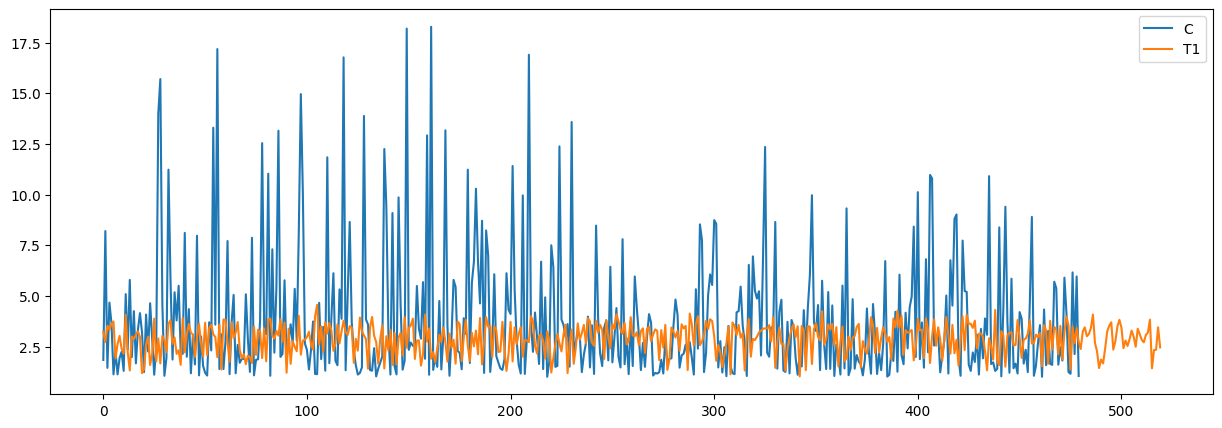

In [12]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["time"], label=treatment)
ax.legend()
pass

## Analyze the experiment

In [13]:
user_level_data = (
  sessions
    .reset_index()
    .groupby(["user", "treatment"])
    .agg(
        {
            "timestamp": "count",
            "tracks": "sum",
            "time": "sum",
            "latency": "sum"
        }
    )
)

user_level_data["sessions"] = user_level_data["timestamp"]
user_level_data["mean_request_latency"] = user_level_data["latency"] / user_level_data["tracks"]
user_level_data["mean_tracks_per_session"] = user_level_data["tracks"] / user_level_data["sessions"]
user_level_data["mean_time_per_session"] = user_level_data["time"] / user_level_data["sessions"]

metrics = [
    "time", 
    "sessions", 
    "mean_request_latency", 
    "mean_tracks_per_session", 
    "mean_time_per_session"
]

user_level_metrics = user_level_data[metrics].copy().reset_index()

In [14]:
treatment_level_metrics = (
    user_level_metrics
    .groupby("treatment")[metrics]
    .agg(["count", "mean", "var"])
)

In [15]:
def dof(n_0, n_1, s2_0, s2_1):
    numerator = (s2_0 / n_0 + s2_1 / n_1) * (s2_0 / n_0 + s2_1 / n_1)
    denominator = s2_0 * s2_0 / n_0 / n_0 / (n_0 - 1) + s2_1 * s2_1 / n_1 / n_1 / (n_1 - 1)
    return numerator / denominator


def ci(n_0, n_1, s2_0, s2_1, alpha=0.05):
    return ss.t.ppf(1 - alpha/2, dof(n_0, n_1, s2_0, s2_1)) * np.sqrt(s2_0 / n_0 + s2_1 / n_1)


effects = []

control = [data for treatment, data in treatment_level_metrics.iterrows() if treatment == "C"][0]

for treatment, row in treatment_level_metrics.iterrows():
    if treatment == "C":
        continue
    
    for metric in metrics:
        control_mean = control[metric]["mean"]
        treatment_mean = row[metric]["mean"]
        
        effect = treatment_mean - control_mean
        conf_int = ci(
            control[metric]["count"],
            row[metric]["count"],
            control[metric]["var"],
            row[metric]["var"],
        )
        effects.append({
            "treatment": treatment,
            "metric": metric,
            "control_mean": control_mean,
            "treatment_mean": treatment_mean,
            "effect": effect / control_mean * 100,
            "lower": (effect - conf_int) / control_mean * 100,
            "upper": (effect + conf_int) / control_mean * 100,
            "significant": (effect + conf_int) * (effect - conf_int) > 0
        })

In [16]:
def color(value):
    return 'color:red;' if value < 0 else 'color:green;'

def background(value):
    return 'color:white;background-color:green' if value else 'color:white;background-color:red'
        

(
    pd.DataFrame(effects)[[
        "treatment", 
        "metric",
        "effect", 
        "upper", 
        "lower", 
        "control_mean", 
        "treatment_mean",
        "significant"
    ]]
    .sort_values(["metric", "treatment"], ascending=False)
    .style
    .map(color, subset=["effect", "upper", "lower"])
    .map(background, subset=["significant"])
)

,treatment,metric,effect,upper,lower,control_mean,treatment_mean,significant
0,T1,time,-24.718673,-16.037491,-33.399855,4.065378,3.060470,True
1,T1,sessions,-0.306748,2.763857,-3.377354,1.066667,1.063395,False
3,T1,mean_tracks_per_session,-11.450496,-7.320233,-15.580760,8.797778,7.790389,True
4,T1,mean_time_per_session,-23.377076,-15.468338,-31.285815,3.767963,2.887123,True
2,T1,mean_request_latency,60.023455,64.567087,55.479822,0.158270,0.253269,True


In [17]:
# Посчитаем среднее количество повторов трека на пользователя
def count_repeats_for_user(df_user):
    seen = set()
    repeats = 0
    for t in df_user["track"]:
        if t in seen:
            repeats += 1
        else:
            seen.add(t)
    return repeats


data_next = (
    data[(data["message"] == "next")&(data["treatment"]== "T1" )]
    .sort_values(["user", "timestamp"])
)


repeats_per_user = data_next.groupby("user").apply(count_repeats_for_user)


mean_repeats = repeats_per_user.mean()
mean_repeats

np.float64(1.278118609406953)

In [18]:
import json

#Посчитаем долю prev_artist = rec_artist
track2artist = {}
with open("/Users/margarita.markova/recsys-course-spring-2026/botify/data/tracks.json") as f:
    for line in f:
        rec = json.loads(line)
        track2artist[rec["track"]] = rec["artist"]


exp_name = "STICKY_ARTIST"
df = data[data["message"] == "next"].copy()
df["treatment"] = df["experiments"].map(lambda e: e.get(exp_name))


df_sticky = df[df["treatment"] != "C"].copy()


df_sticky["prev_artist"] = df_sticky["track"].map(track2artist)
df_sticky["rec_artist"] = df_sticky["recommendation"].map(track2artist)


share_same = (df_sticky["prev_artist"] == df_sticky["rec_artist"]).mean()
share_same

np.float64(1.0)